# Ejercicio 6 - Parquet versus tabla DuckDB

Grafica los resultados de `python scripts/benchmark.py`, que ejecuta las mismas consultas sobre los archivos Parquet y sobre una tabla materializada, en cuatro volumenes de datos. El benchmark tarda varios minutos, por eso no se ejecuta desde aqui: este notebook solo lee `docs/resultados/ejercicio6/*.csv`.

Analisis: `docs/ejercicio6_benchmark.md`. Tablas completas y SQL: `docs/resultados/ejercicio6.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))   # notebooks/ -> scripts/
from lab import conectar, ejecutar_sql, RAIZ_REPO

import matplotlib.pyplot as plt
import pandas as pd
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

DIR_FIG = RAIZ_REPO / "docs" / "figuras"
DIR_FIG.mkdir(parents=True, exist_ok=True)
# Dos series por grafica: posiciones 1 y 2 de una paleta categorica validada
# (contraste >= 3:1 sobre blanco y separables con daltonismo).
AZUL, NARANJA = "#2a78d6", "#eb6834"
TINTA, TINTA_2, REJILLA = "#0b0b0b", "#52514e", "#e6e5e0"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": TINTA_2, "axes.labelcolor": TINTA_2, "xtick.color": TINTA_2,
    "ytick.color": TINTA_2, "axes.grid": True, "grid.color": REJILLA, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "lines.linewidth": 2, "lines.markersize": 6,
    "legend.frameon": False,
})

def guardar(fig, nombre):
    fig.tight_layout()
    fig.savefig(DIR_FIG / f"{nombre}.png", bbox_inches="tight")
    plt.show()

DIR_RES = RAIZ_REPO / "docs" / "resultados" / "ejercicio6"
resumen = pd.read_csv(DIR_RES / "resumen.csv")
mat = pd.read_csv(DIR_RES / "materializacion.csv")
validez = pd.read_csv(DIR_RES / "validez.csv")
COLOR_MODO = {"parquet": AZUL, "tabla": NARANJA}
ETIQUETA_MODO = {"parquet": "Parquet (vista)", "tabla": "Tabla DuckDB"}
NOMBRES = {
    "B1": "B1 Conteo por tipo", "B2": "B2 Viajes por mes (P1)",
    "B3": "B3 Hora x dia (P2)", "B4": "B4 Percentiles (P3)",
    "B5": "B5 Join con zonas (P5)", "B6": "B6 Reglas de calidad (P9)",
    "B7": "B7 Filtro selectivo (1 dia, JFK)",
}
mat

,escenario,nombre,meses,archivos,filas,mib_parquet,mib_duckdb,segundos_crear_tabla,segundos_total
0,1m,1 mes,1,2,3765161,62.1,103.0,7.28,7.59
1,3m,3 meses,3,6,11199059,184.8,307.8,13.98,14.65
2,2026,2026,8,16,30040469,495.7,842.5,36.93,39.37
3,todos,todos,20,40,71870407,1171.7,1995.0,75.10,79.18


## 6.5 - 6.6 Tiempo por consulta segun el volumen de datos

Mediana de las repeticiones. Ambos ejes en escala logaritmica: una pendiente de 1 significa que el tiempo crece en proporcion a las filas; la distancia vertical entre las lineas es la razon Parquet / tabla.

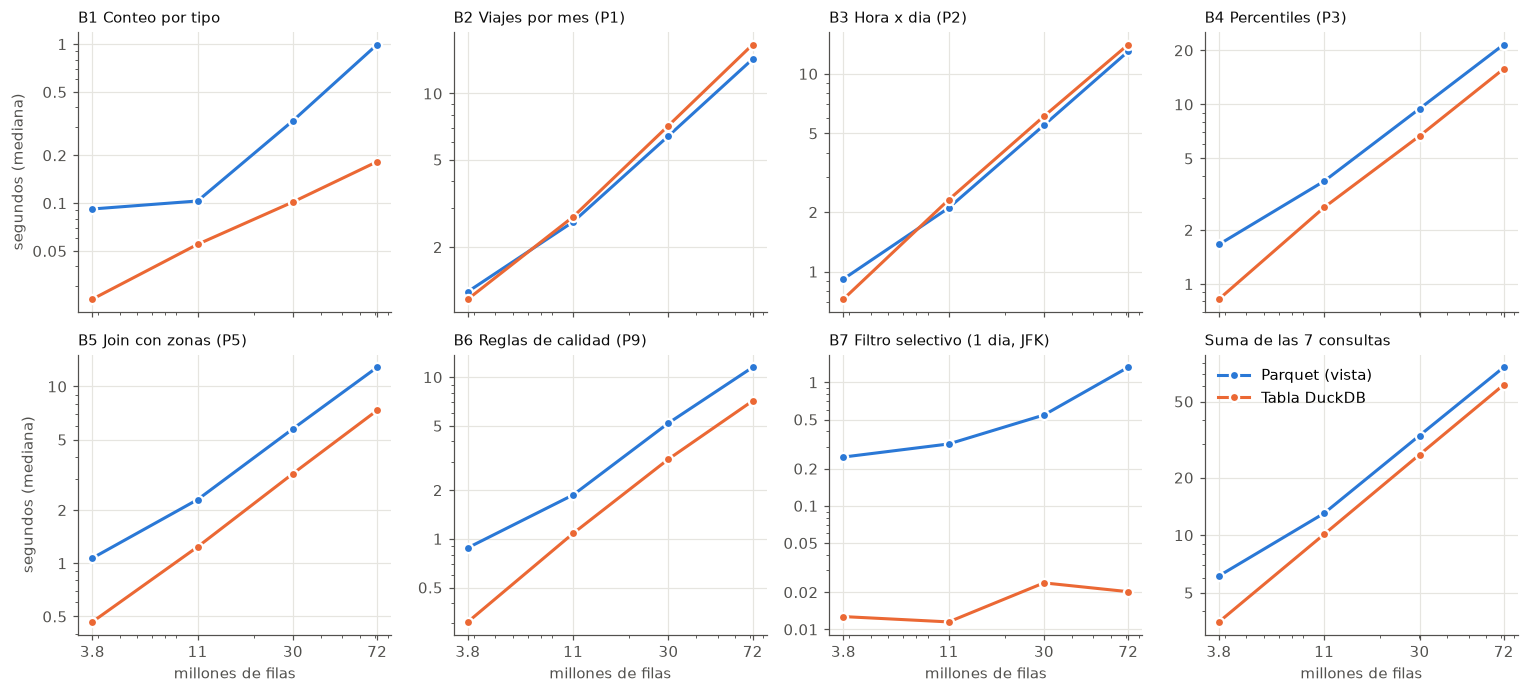

In [2]:
from matplotlib.ticker import FixedLocator, LogLocator, NullFormatter

consultas = sorted(resumen.consulta.unique())
millones = sorted(resumen.filas_escenario.unique() / 1e6)

def ejes_log(eje):
    """Escala log en ambos ejes; en x solo las marcas de los escenarios."""
    eje.set_xscale("log")
    eje.set_yscale("log")
    eje.xaxis.set_major_locator(FixedLocator(millones))
    eje.xaxis.set_major_formatter(lambda v, _: f"{v:.1f}" if v < 10 else f"{v:.0f}")
    eje.xaxis.set_minor_formatter(NullFormatter())
    eje.yaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    eje.yaxis.set_major_formatter(lambda v, _: f"{v:g}")
    eje.yaxis.set_minor_formatter(NullFormatter())

fig, ejes = plt.subplots(2, 4, figsize=(14, 6.4), sharex=True)
for eje, cid in zip(ejes.flat, consultas):
    d = resumen[resumen.consulta == cid]
    for modo, color in COLOR_MODO.items():
        s = d[d.modo == modo].sort_values("filas_escenario")
        eje.plot(s.filas_escenario / 1e6, s.mediana_s, marker="o", color=color,
                 label=ETIQUETA_MODO[modo], markeredgecolor="white", markeredgewidth=1.5)
    ejes_log(eje)
    eje.set_title(NOMBRES.get(cid, cid), color=TINTA, loc="left", fontsize=10)
for eje in ejes[:, 0]:
    eje.set_ylabel("segundos (mediana)")
for eje in ejes[1, :]:
    eje.set_xlabel("millones de filas")
# El ultimo panel lleva la leyenda y el resumen del total.
ultimo = ejes.flat[len(consultas)]
total = resumen.groupby(["filas_escenario", "modo"]).mediana_s.sum().unstack()
for modo, color in COLOR_MODO.items():
    ultimo.plot(total.index / 1e6, total[modo], marker="o", color=color, label=ETIQUETA_MODO[modo],
                markeredgecolor="white", markeredgewidth=1.5)
ejes_log(ultimo)
ultimo.set_title("Suma de las 7 consultas", color=TINTA, loc="left", fontsize=10)
ultimo.set_xlabel("millones de filas")
ultimo.legend(loc="upper left")
for eje in ejes.flat[len(consultas) + 1:]:
    eje.set_visible(False)
guardar(fig, "e6_tiempos_por_consulta")

## Razon Parquet / tabla por consulta y escenario

Valores > 1: la tabla materializada fue mas rapida.

In [3]:
razon = (resumen.pivot_table(index=["consulta", "escenario"], columns="modo", values="mediana_s")
         .assign(parquet_sobre_tabla=lambda d: d.parquet / d.tabla)
         .parquet_sobre_tabla.unstack("escenario")[list(mat.escenario)])
razon.round(1)

escenario,1m,3m,2026,todos
consulta,,,,
B1,3.7,1.9,3.2,5.5
B2,1.1,0.9,0.9,0.9
B3,1.3,0.9,0.9,0.9
B4,2.0,1.4,1.4,1.4
B5,2.3,1.9,1.8,1.8
B6,2.9,1.7,1.7,1.6
B7,19.6,27.6,22.9,65.6


## Costo de materializar: espacio en disco y tiempo de creacion

Dos medidas con escalas distintas, en dos graficas.

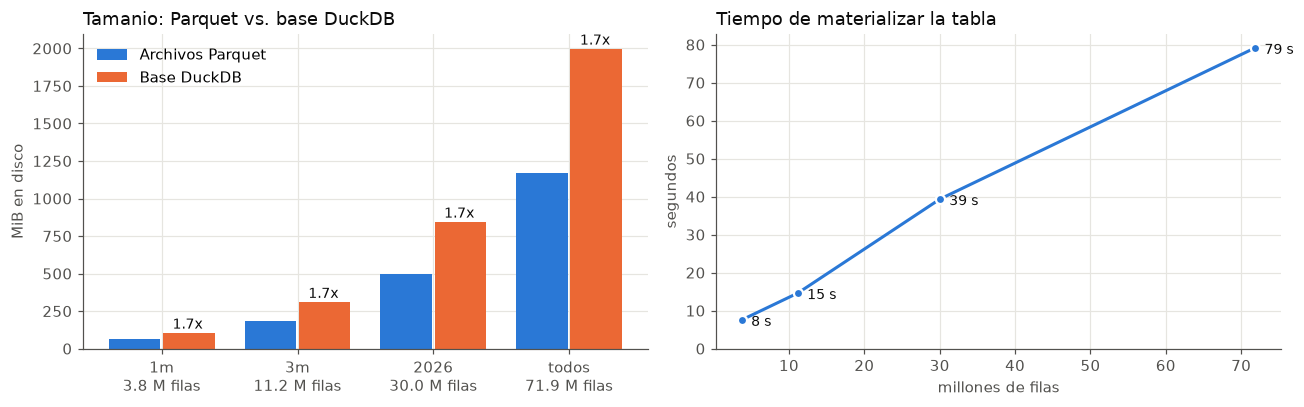

In [4]:
fig, (e1, e2) = plt.subplots(1, 2, figsize=(12, 3.8))
x = range(len(mat))
ancho = 0.38
e1.bar([i - ancho / 2 - 0.01 for i in x], mat.mib_parquet, ancho, color=AZUL, label="Archivos Parquet")
e1.bar([i + ancho / 2 + 0.01 for i in x], mat.mib_duckdb, ancho, color=NARANJA, label="Base DuckDB")
for i, r in mat.iterrows():
    e1.annotate(f"{r.mib_duckdb / r.mib_parquet:.1f}x", (i + ancho / 2, r.mib_duckdb), xytext=(0, 3),
                textcoords="offset points", ha="center", fontsize=9, color=TINTA)
e1.set_xticks(list(x), [f"{e}\n{f / 1e6:.1f} M filas" for e, f in zip(mat.escenario, mat.filas)])
e1.set_ylabel("MiB en disco")
e1.set_title("Tamanio: Parquet vs. base DuckDB", color=TINTA, loc="left")
e1.legend(loc="upper left")

e2.plot(mat.filas / 1e6, mat.segundos_total, marker="o", color=AZUL, markeredgecolor="white", markeredgewidth=1.5)
for _, r in mat.iterrows():
    e2.annotate(f"{r.segundos_total:.0f} s", (r.filas / 1e6, r.segundos_total), xytext=(6, -4),
                textcoords="offset points", fontsize=9, color=TINTA)
e2.set_xlabel("millones de filas")
e2.set_ylabel("segundos")
e2.set_ylim(bottom=0)
e2.set_title("Tiempo de materializar la tabla", color=TINTA, loc="left")
guardar(fig, "e6_costo_materializar")

## Validez de la comparacion

Ambos modos deben devolver el mismo resultado; `aprox` corresponde a percentiles aproximados (`approx_quantile`).

In [5]:
validez.pivot(index="consulta", columns="escenario", values="resultado_parquet_vs_tabla")[list(mat.escenario)]

escenario,1m,3m,2026,todos
consulta,,,,
B1,igual,igual,igual,igual
B2,igual,igual,igual,igual
B3,igual,igual,igual,igual
B4,aprox,aprox,aprox,aprox
B5,igual,igual,igual,igual
B6,igual,igual,igual,igual
B7,igual,igual,igual,igual
